In [26]:
# --- Cell 1: data ---
import numpy as np
import pandas as pd

# Wind + solar share of EU-27 electricity generation, %.
# Anchor points (2011, 2021, 2024, 2025) from Eurostat / Ember European Electricity Review.
# Intervening years interpolated. For a fully sourced series, use Ember's Yearly Electricity
# Data (Europe): https://ourworldindata.org/grapher/share-electricity-wind-solar
vre_share = pd.Series(
    {
        2004:  2.1, 2005:  2.6, 2006:  3.2, 2007:  3.9, 2008:  4.7,
        2009:  5, 2010:  5.6, 2011:  6.0,   # anchor
        2012:  9.0, 2013: 10.0, 2014: 11.0, 2015: 12.4, 2016: 12.5,
        2017: 14.0, 2018: 15.2, 2019: 17.3, 2020: 18.9,
        2021: 19.0,                            # anchor
        2022: 22.0, 2023: 26.0,
        2024: 29.0,                            # anchor (Ember 2025 review)
        2025: 30.0,                            # anchor (Ember 2026 review)
    },
    name="wind_solar_share_pct",
)

# 2030 projection: RED III targets 42.5% renewables in gross final energy consumption,
# implying ~65-70% renewables in electricity. Non-VRE renewables (hydro + biomass) sit at
# ~15-17%, leaving VRE at roughly 50-55% by 2030. Band represents that uncertainty.
projection_year   = 2030
projection_value  = 50.0
projection_band   = 5.0

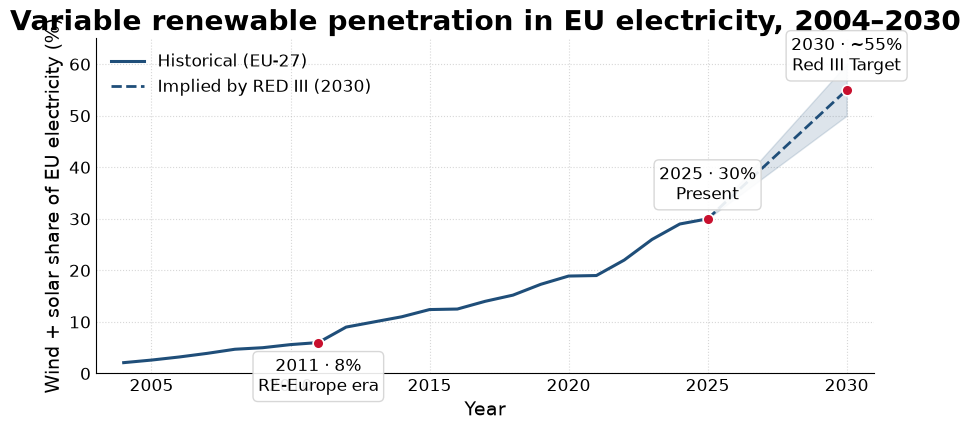

In [18]:
# --- Cell 2: plot ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))  # 16:9-ish, sized for widescreen beamer

NAVY = "#1f4e79"
RED  = "#c8102e"

# Historical trajectory
ax.plot(vre_share.index, vre_share.values,
        color=NAVY, linewidth=2.2, zorder=3, label="Historical (EU-27)")

# Projection segment 2025 -> 2030 with uncertainty band
ax.plot([2025, projection_year], [vre_share[2025], projection_value],
        color=NAVY, linewidth=2.0, linestyle="--", zorder=3,
        label="Implied by RED III (2030)")
ax.fill_between(
    [2025, projection_year],
    [vre_share[2025], projection_value - projection_band],
    [vre_share[2025], projection_value + projection_band],
    color=NAVY, alpha=0.15, zorder=2,
)

# Highlighted anchor points
anchors = [
    (2011, vre_share[2011],   "2011 · 8%\nRE-Europe era", -14, "top"),
    (2025, vre_share[2025],   "2025 · 30%\nPresent",       14, "bottom"),
    (2030, projection_value,  "2030 · ~55%\nRed III Target",      14, "bottom"),
]
for year, val, label, y_off, va in anchors:
    ax.scatter([year], [val], color=RED, s=60, zorder=5,
               edgecolor="white", linewidth=1.2)
    ax.annotate(
        label, xy=(year, val), xytext=(0, y_off),
        textcoords="offset pixels", ha="center", va=va, fontsize=12,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="lightgray", alpha=0.9),
    )

# Cosmetics
ax.set_xlabel("Year")
ax.set_ylabel("Wind + solar share of EU electricity (%)")
ax.set_title("Variable renewable penetration in EU electricity, 2004–2030")
ax.set_ylim(0, 65)
ax.set_xlim(2003, 2031)
ax.grid(True, linestyle=":", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper left", frameon=False)

plt.tight_layout()
plt.savefig("vre_penetration.pdf", bbox_inches="tight", transparent=True)
plt.show()

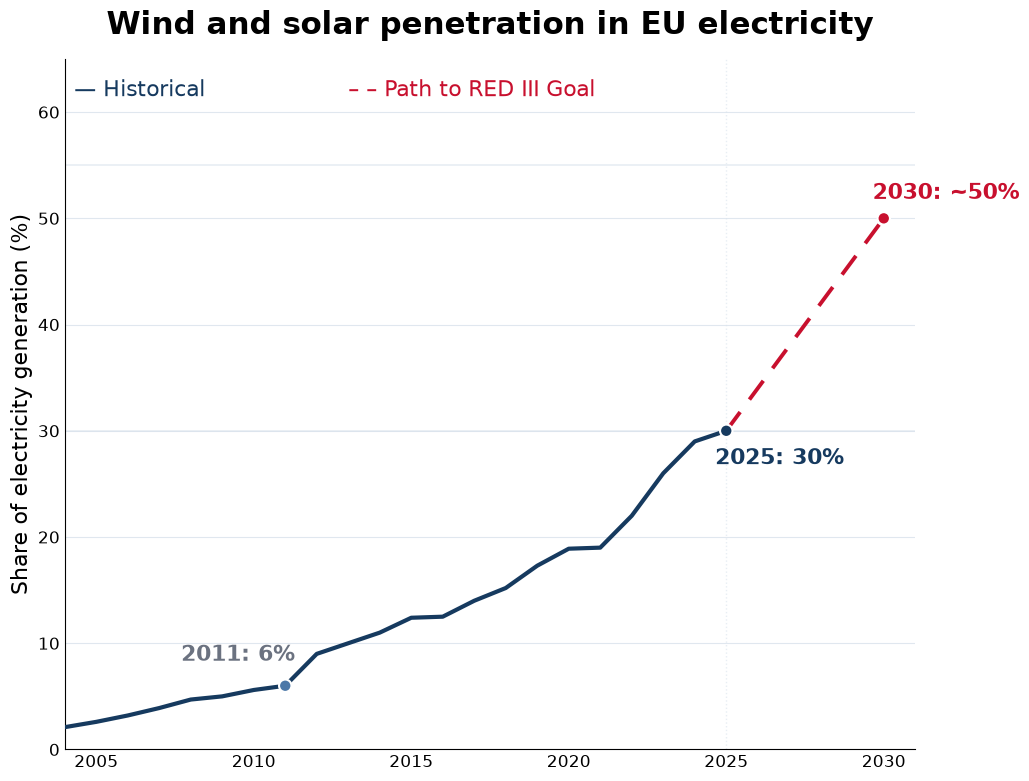

In [44]:
# --- Cell 2: plot ---
import matplotlib.pyplot as plt
import matplotlib as mpl

# Global style for slides
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 13,
    "axes.titlesize": 20,
    "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "axes.labelweight": "regular",
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "xtick.major.size": 0,
    "ytick.major.size": 0,
    "savefig.dpi": 300,
})

NAVY = "#163A5F"
BLUE = "#4C78A8"
RED = "#C8102E"
GREY = "#6B7280"
LIGHT = "#E8EEF4"

fig, ax = plt.subplots(figsize=(10.5, 8))  # better for widescreen slides

# Historical trajectory
ax.plot(
    vre_share.index,
    vre_share.values,
    color=NAVY,
    linewidth=3,
    solid_capstyle="round",
    zorder=3,
)

# Projection and uncertainty
ax.plot(
    [2025, projection_year],
    [vre_share[2025], projection_value],
    color=RED,
    linewidth=2.8,
    linestyle=(0, (6, 4)),
    solid_capstyle="round",
    zorder=4,
)


# Anchor points
ax.scatter(
    [2011, 2025, 2030],
    [vre_share[2011], vre_share[2025], projection_value],
    s=80,
    color=[BLUE, NAVY, RED],
    edgecolor="white",
    linewidth=1.5,
    zorder=5,
)

# Direct labels instead of bulky boxes
ax.annotate(
    "2011: 6%",
    xy=(2011, vre_share[2011]),
    xytext=(-75, 18),
    textcoords="offset points",
    fontsize=16,
    color=GREY,
    weight="semibold",
)

ax.annotate(
    "2025: 30%",
    xy=(2025, vre_share[2025]),
    xytext=(-8, -24),
    textcoords="offset points",
    fontsize=16,
    color=NAVY,
    weight="semibold",
)

ax.annotate(
    "2030: ~50%",
    xy=(2030, projection_value),
    xytext=(-8, 14),
    textcoords="offset points",
    fontsize=16,
    color=RED,
    weight="bold",
)

# Subtle reference lines
ax.axhline(30, color=LIGHT, linewidth=1.2, zorder=0)
ax.axhline(55, color=LIGHT, linewidth=1.2, zorder=0)
ax.axvline(2025, color=LIGHT, linewidth=1.0, linestyle=":", zorder=0)

# Titles and labels
ax.set_title("Wind and solar penetration in EU electricity", loc="center", pad=18, fontsize = 22)


ax.set_ylabel("Share of electricity generation (%)", fontsize = 16)
ax.set_xlabel("")

# Axis limits and ticks
ax.set_xlim(2004, 2031)
ax.set_ylim(0, 65)
ax.set_xticks([2005, 2010, 2015, 2020, 2025, 2030])
ax.set_yticks([0, 10, 20, 30, 40, 50, 60])

# Minimal grid
ax.grid(axis="y", linestyle="-", linewidth=0.8, color="#D9E2EC", alpha=0.8)
ax.grid(axis="x", visible=False)

# Inline legend substitute
ax.text(2004.3, 61.5, "— Historical", color=NAVY, fontsize=16)
ax.text(2013.0, 61.5, "– – Path to RED III Goal", color=RED, fontsize=16)

# Clean background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

plt.tight_layout()
plt.savefig("vre_penetration.pdf", bbox_inches="tight", transparent=False)
plt.show()